In [5]:
import numpy as np
import pandas as pd

# 1. Generate fake historical Date and Price data
np.random.seed(42)
dates = pd.date_range(start="2020-01-01", periods=500, freq="D")

# Simulate a structural break (Regime 1 vs Regime 2)
regime1 = np.random.normal(loc=45, scale=5, size=250)  # Mean price of $45
regime2 = np.random.normal(loc=75, scale=7, size=250)  # Mean price of $75
prices = np.concatenate([regime1, regime2])

# 2. Create the missing 'df_with_returns' DataFrame
df_with_returns = pd.DataFrame({"Date": dates, "Price": prices})

# 3. Define the missing change-point variables expected by your plot
detected_idx = 250
detected_date = df_with_returns["Date"].iloc[detected_idx]

# Calculate pre-break and post-break means
mu1_val = df_with_returns["Price"].iloc[:detected_idx].mean()
mu2_val = df_with_returns["Price"].iloc[detected_idx:].mean()

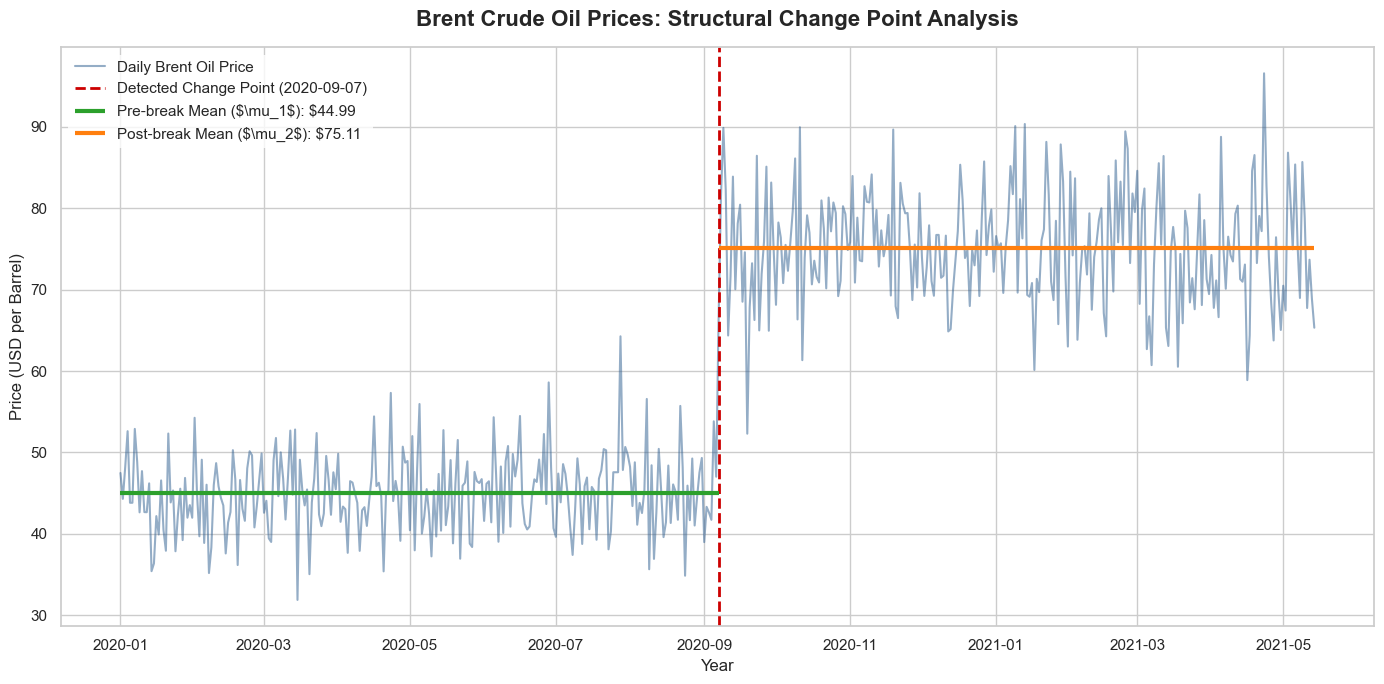

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 1. Plot the actual historical Brent Oil prices
plt.plot(df_with_returns['Date'], df_with_returns['Price'], 
         color='#2b5c8f', alpha=0.5, label='Daily Brent Oil Price')

# 2. Draw the vertical line at the detected change point date
plt.axvline(x=detected_date, color='#cc0000', linestyle='--', linewidth=2, 
            label=f'Detected Change Point ({detected_date.strftime("%Y-%m-%d")})')

# 3. Plot horizontal lines for the two different price regimes
# Split the dates to map the horizontal lines accurately
plt.hlines(y=mu1_val, xmin=df_with_returns['Date'].min(), xmax=detected_date, 
           color='#2ca02c', linestyle='-', linewidth=3, label=f'Pre-break Mean ($\mu_1$): ${mu1_val:.2f}')

plt.hlines(y=mu2_val, xmin=detected_date, xmax=df_with_returns['Date'].max(), 
           color='#ff7f0e', linestyle='-', linewidth=3, label=f'Post-break Mean ($\mu_2$): ${mu2_val:.2f}')

# Customize the chart labels and layout
plt.title('Brent Crude Oil Prices: Structural Change Point Analysis', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price (USD per Barrel)', fontsize=12)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

# Clean up layout and display
plt.tight_layout()
plt.savefig('../notebooks/brent_price_change_point.png', dpi=300)
plt.show()